# Data Models

In [60]:
# Import pandas for data handling
import pandas as pd

# Train/test split
from sklearn.model_selection import train_test_split

# Pipeline tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [61]:
# Load dataset
df = pd.read_csv("../data/startup_success_dataset.csv")

# Remove duplicates
df = df.drop_duplicates()

# Quick check
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 11)


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


In [62]:
# Features (inputs)
X = df.drop("outcome", axis=1)

# Target (what we predict)
y = df["outcome"]

In [63]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [64]:
# Numerical columns (we scale these)
num_cols = [
    "funding_rounds",
    "founder_experience_years",
    "team_size",
    "market_size_billion",
    "product_traction_users",
    "burn_rate_million",
    "revenue_million"
]

# Categorical columns (we one-hot encode these)
cat_cols = [
    "investor_type",
    "sector",
    "founder_background"
]

# Clean one-hot encoder (IMPORTANT: no prefix clutter)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

## Logistic Regression Model

In [66]:
# Logistic Regression pipeline
lr_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

# Train model
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

In [67]:
print("=== Logistic Regression Results ===")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average="weighted")
recall = recall_score(y_test, y_pred_lr, average="weighted")
f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("\nStored Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

=== Logistic Regression Results ===

Confusion Matrix:
[[4798 2238 1431]
 [2475 8577   70]
 [  70    1  340]]

Classification Report:
              precision    recall  f1-score   support

 Acquisition       0.65      0.57      0.61      8467
     Failure       0.79      0.77      0.78     11122
         IPO       0.18      0.83      0.30       411

    accuracy                           0.69     20000
   macro avg       0.54      0.72      0.56     20000
weighted avg       0.72      0.69      0.70     20000


Stored Metrics:
Accuracy: 0.6857
Precision: 0.7214
Recall: 0.6857
F1 Score: 0.698


## Random Forest Model

In [68]:
# Random Forest pipeline
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

In [69]:
print("=== Random Forest Results ===")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("\nStored Metrics:")
print("Accuracy:", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1 Score:", round(f1_rf, 4))

=== Random Forest Results ===

Confusion Matrix:
[[5576 2879   12]
 [2010 9112    0]
 [ 374    1   36]]

Classification Report:
              precision    recall  f1-score   support

 Acquisition       0.70      0.66      0.68      8467
     Failure       0.76      0.82      0.79     11122
         IPO       0.75      0.09      0.16       411

    accuracy                           0.74     20000
   macro avg       0.74      0.52      0.54     20000
weighted avg       0.73      0.74      0.73     20000


Stored Metrics:
Accuracy: 0.7362
Precision: 0.7345
Recall: 0.7362
F1 Score: 0.7291


## ROC Curves for IPO Class

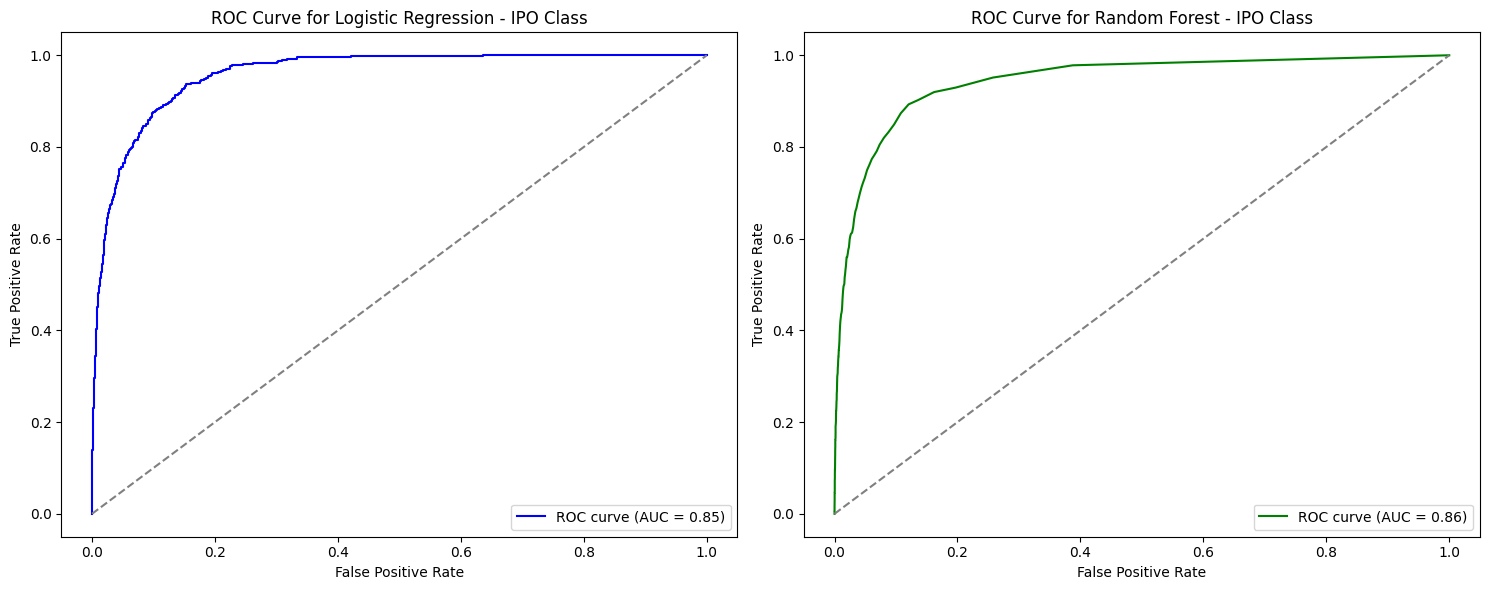

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression Predictions (Probability)
y_prob_lr = lr_model.predict_proba(X_test)  # Get probabilities for all classes
y_prob_lr_ipo = y_prob_lr[:, 2]  # Extract probabilities for the IPO class (class 2)

# ROC Curve for IPO Class (Logistic Regression)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr_ipo, pos_label='IPO')

# Calculate AUC for IPO Class (Logistic Regression)
auc_lr = roc_auc_score(y_test, y_prob_lr, multi_class='ovr', labels=['Acquisition', 'Failure', 'IPO'])

# Random Forest Predictions (Probability)
y_prob_rf = rf_model.predict_proba(X_test)  # Get probabilities for all classes
y_prob_rf_ipo = y_prob_rf[:, 2]  # Extract probabilities for the IPO class (class 2)

# ROC Curve for IPO Class (Random Forest)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_ipo, pos_label='IPO')

# Calculate AUC for IPO Class (Random Forest)
auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class='ovr', labels=['Acquisition', 'Failure', 'IPO'])

# Create side-by-side plots for both ROC curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns

# Plot ROC Curve for Logistic Regression (IPO Class)
axes[0].plot(fpr_lr, tpr_lr, color='blue', label=f'ROC curve (AUC = {auc_lr:.2f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('ROC Curve for Logistic Regression - IPO Class')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Plot ROC Curve for Random Forest (IPO Class)
axes[1].plot(fpr_rf, tpr_rf, color='green', label=f'ROC curve (AUC = {auc_rf:.2f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('ROC Curve for Random Forest - IPO Class')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

## Model Performance Comparison Table

In [80]:
# Calculate AUC for Logistic Regression (IPO Class)
auc_lr = roc_auc_score(y_test, y_prob_lr, multi_class='ovr', labels=['Acquisition', 'Failure', 'IPO'])

# Calculate AUC for Random Forest (IPO Class)
auc_rf = roc_auc_score(y_test, y_prob_rf, multi_class='ovr', labels=['Acquisition', 'Failure', 'IPO'])

# Update Model Performance Comparison Table with AUC
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1 Score": [f1, f1_rf],
    "ROC AUC": [auc_lr, auc_rf]  # Add AUC to the table
})

# Display the updated comparison table
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.68575,0.721400,0.68575,0.697992,0.845781
1,Random Forest,0.73620,0.734517,0.73620,0.729080,0.859523


## Feature Importance Comparison (Bar Chart)

                    Feature  Importance
7           revenue_million    0.268398
6    product_traction_users    0.215386
2  founder_experience_years    0.085743
9                 team_size    0.084675
5       market_size_billion    0.079692
0         burn_rate_million    0.079351
3            funding_rounds    0.071470
8                    sector    0.050010
4             investor_type    0.032661
1        founder_background    0.032614


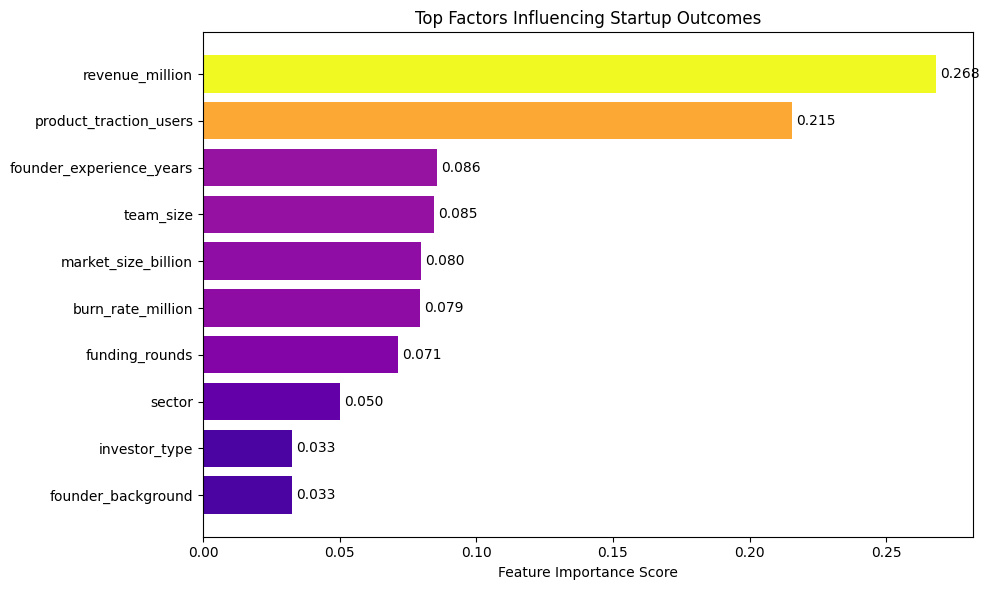

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# Get trained Random Forest model from pipeline
rf = rf_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Get importance values
importances = rf.feature_importances_

# Function to simplify feature names
def simplify(name):
    if "funding_rounds" in name:
        return "funding_rounds"
    elif "founder_experience" in name:
        return "founder_experience_years"
    elif "team_size" in name:
        return "team_size"
    elif "market_size" in name:
        return "market_size_billion"
    elif "product_traction" in name:
        return "product_traction_users"
    elif "burn_rate" in name:
        return "burn_rate_million"
    elif "revenue" in name:
        return "revenue_million"
    elif "investor_type" in name:
        return "investor_type"
    elif "sector" in name:
        return "sector"
    elif "founder_background" in name:
        return "founder_background"
    else:
        return name

# Clean feature names
clean_names = []

for name in feature_names:
    cleaned = simplify(name)
    clean_names.append(cleaned)

# Build dataframe
feature_importance = pd.DataFrame({
    "Feature": clean_names,
    "Importance": importances
})

# Merge duplicates
feature_importance = feature_importance.groupby(
    "Feature",
    as_index=False
).sum()

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

# Top 10 features
top_features = feature_importance.tail(10)

# Plot
plt.figure(figsize=(10,6))

colors = plt.cm.plasma(
    top_features["Importance"] / top_features["Importance"].max()
)

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=colors
)

# Print full table
feature_importance_display = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_display)

# Add value labels on bars
plt.bar_label(bars, fmt="%.3f", padding=3)

plt.title("Top Factors Influencing Startup Outcomes")
plt.xlabel("Feature Importance Score")

plt.tight_layout()
plt.show()